<a href="https://colab.research.google.com/github/edanielson-star/Taylor-Rule-NN-Approx/blob/main/TaylorRule4Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**From a series of application of modern interpolation methods for economics: written by [Mahdi E Kahou](https://sites.google.com/site/mahdiebrahimikahou/about-me)**


Note: This notebook should take at most **50 seconds** to run. From `Runtime` choose `Run all` to run this code.

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib import cm

In [6]:
fontsize= 14
ticksize = 14
figsize = (10, 4.5)
params = {'font.family':'serif',
    "figure.figsize":figsize,
    'figure.dpi': 80,
    'figure.edgecolor': 'k',
    'font.size': fontsize,
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'xtick.labelsize': ticksize,
    'ytick.labelsize': ticksize
}
plt.rcParams.update(params)

## Setting up the model parameters

In [3]:
class Params:
    def __init__(self,
                 alpha = 1.0/3.0,
                 rho = 0.1111,
                 delta = 0.1,
                 k_0 = 1.0,
                 sigma = 1.0, #CRRA coeff,
                ):
        self.alpha = alpha
        self.rho = rho
        self.delta = delta
        self.k_0 = k_0
        self.sigma = sigma

In [4]:
# 1. Parameter Calibration (Benhabib, Schmitt-Grohé, and Uribe 2001)
A = 2              # Active Taylor Rule coefficient
r = 0.018 / 4        # Steady-state real rate (quarterly)
pi_star = 0.042 / 4  # Central bank target inflation
R_star = r + pi_star # Target nominal interest rate

# Structural parameters
omega = -1.0
eta = -6.0
v = 1.0
alpha = 0.7
gamma = 50.0
x = 0.5

In [70]:
class NN_macro(nn.Module):
    def __init__(self, dim_hidden=128, layers=4):
        super().__init__()
        torch.manual_seed(123)
        module = []
        module.append(nn.Linear(1, dim_hidden))
        module.append(nn.Tanh())

        for i in range(layers-1):
            module.append(nn.Linear(dim_hidden, dim_hidden))
            module.append(nn.Tanh())

        module.append(nn.Linear(dim_hidden, 2))
        self.q = nn.Sequential(*module)
        self.softplus = nn.Softplus(beta=1.0)

    def forward(self, x):
        out = self.q(x)
        lam = self.softplus(out[:, [0]]) + 1e-5 # lambda must be strictly positive
        pi = out[:, [1]] # pi can be negative
        return torch.cat((lam, pi), dim=1)

In [71]:
def R_torch(pi):
    return R_star * torch.exp((A / R_star) * (pi - pi_star))

def G_macro(model, t):
    out = model(t)
    lam = out[:, [0]]
    pi = out[:, [1]]

    # d(lambda)/dt
    dlam = lam * (r + pi - R_torch(pi))

    # d(pi)/dt
    term1 = r * (pi - pi_star)
    term2 = -((1 + eta) / gamma) * (lam ** (omega / (omega - 1))) * (x ** (1 / (1 - omega)))
    term3 = (eta / (gamma * alpha)) * (lam ** ((1 + v) / (alpha * (omega - 1)))) * (x ** ((1 + v) / (alpha * (1 - omega))))
    dpi = term1 + term2 + term3

    return torch.stack((dlam, dpi), 1).squeeze()

In [72]:
q_hat_macro = NN_macro()
learning_rate = 1e-3
optimizer_macro = torch.optim.Adam(q_hat_macro.parameters(), lr=learning_rate)
scheduler_macro = torch.optim.lr_scheduler.StepLR(optimizer_macro, step_size=100, gamma=0.8)

num_epochs_macro = 1000
pi_0 = 0.011 # Initial condition for pi

for epoch in range(num_epochs_macro):
    for i, time in enumerate(train):
        time_zero = torch.zeros([1,1])

        res_ode = derivative_back(q_hat_macro, time) - G_macro(q_hat_macro, time)
        # Initial condition on pi (index 1), lambda_0 is learned
        res_init = q_hat_macro(time_zero)[:, [1]] - pi_0

        loss_ode = res_ode.pow(2).mean()
        loss_init = res_init.pow(2).mean()

        # Greatly increase the weight of the initial condition so it isn't overpowered
        loss = loss_ode + 100.0 * loss_init

        optimizer_macro.zero_grad()
        loss.backward()

        # Optional: clip gradients to prevent the exponential Taylor rule from exploding the weights
        torch.nn.utils.clip_grad_norm_(q_hat_macro.parameters(), max_norm=1.0)

        optimizer_macro.step()

    scheduler_macro.step()
    if epoch == 0:
         print('epoch , loss , loss_ode , loss_initial , lr_rate')
    if epoch % 250 == 0:
         print(f"{epoch} , {loss.item():.2e} , {loss_ode.item():.2e} , {loss_init.item():.2e} , {get_lr(optimizer_macro):.2e}")

epoch , loss , loss_ode , loss_initial , lr_rate
0 , 2.32e-02 , 3.02e-03 , 2.02e-04 , 1.00e-03
250 , 5.24e-06 , 6.16e-07 , 4.63e-08 , 6.40e-04
500 , 2.05e-06 , 6.26e-08 , 1.99e-08 , 3.28e-04
750 , 1.55e-08 , 1.52e-08 , 3.41e-12 , 2.10e-04


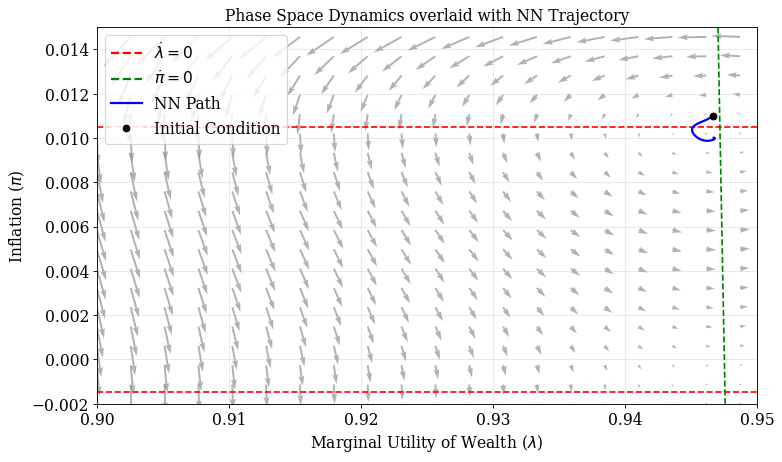

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Numpy equivalent of the vector field
def vector_field_np(lam, pi):
    lam = np.maximum(lam, 1e-5)
    dlam = lam * (r + pi - R_star * np.exp((A / R_star) * (pi - pi_star)))
    term1 = r * (pi - pi_star)
    term2 = -((1 + eta) / gamma) * (lam ** (omega / (omega - 1))) * (x ** (1 / (1 - omega)))
    term3 = (eta / (gamma * alpha)) * (lam ** ((1 + v) / (alpha * (omega - 1)))) * (x ** ((1 + v) / (alpha * (1 - omega))))
    dpi = term1 + term2 + term3
    return dlam, dpi

# Create a grid covering the trajectory bounds
L_min, L_max = 0.90, 0.95
P_min, P_max = -0.002, 0.015

L_grid, P_grid = np.meshgrid(
    np.linspace(L_min, L_max, 40),
    np.linspace(P_min, P_max, 40)
)

# Calculate vector field
dL, dP = vector_field_np(L_grid, P_grid)

plt.figure(figsize=(10, 6))

# Quiver plot for the vector field
plt.quiver(L_grid[::2, ::2], P_grid[::2, ::2], dL[::2, ::2], dP[::2, ::2], color='gray', alpha=0.6)

# Plot nullclines
plt.contour(L_grid, P_grid, dL, levels=[0], colors='r', linestyles='--')
plt.contour(L_grid, P_grid, dP, levels=[0], colors='g', linestyles='--')

# Plot the NN learned trajectory
plt.plot(lam_hat_path, pi_hat_path, color='blue', linewidth=2, label='NN Approximate Path')
plt.scatter(lam_hat_path[0], pi_hat_path[0], color='black', zorder=5, label='Start')

plt.ylabel(r"Inflation ($\pi$)")
plt.xlabel(r"Marginal Utility of Wealth ($\lambda$)")
plt.title("Phase Space Dynamics overlaid with NN Trajectory")

# Custom legend
custom_lines = [Line2D([0], [0], color='r', linestyle='--', lw=2),
                Line2D([0], [0], color='g', linestyle='--', lw=2),
                Line2D([0], [0], color='blue', lw=2),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8)]
plt.legend(custom_lines, [r'$\dot{\lambda}=0$', r'$\dot{\pi}=0$', 'NN Path', 'Initial Condition'], loc='best')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

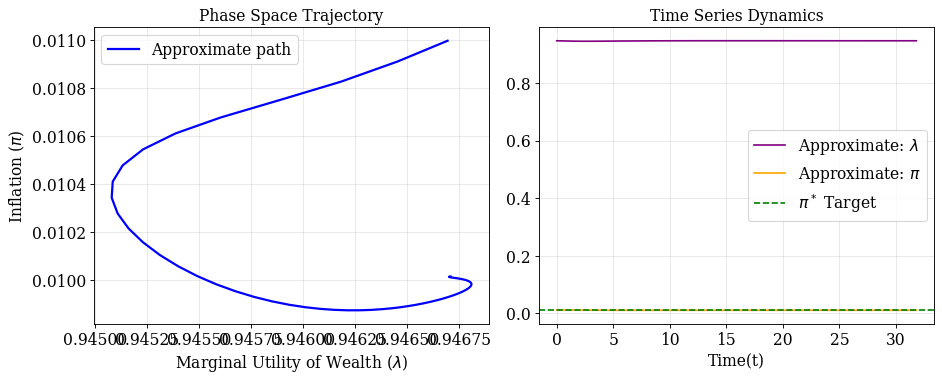

In [73]:
time_test_macro = Grid_data().grid
lam_hat_path = q_hat_macro(time_test_macro)[:, [0]].detach().numpy()
pi_hat_path = q_hat_macro(time_test_macro)[:, [1]].detach().numpy()
time_np = time_test_macro.numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lam_hat_path, pi_hat_path, label="Approximate path", color='blue', linewidth=2)
plt.ylabel(r"Inflation ($\pi$)")
plt.xlabel(r"Marginal Utility of Wealth ($\lambda$)")
plt.title("Phase Space Trajectory")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time_np, lam_hat_path, label=r"Approximate: $\lambda$", color='purple')
plt.plot(time_np, pi_hat_path, label=r"Approximate: $\pi$", color='orange')
plt.axhline(y=pi_star, color='g', linestyle='--', label=r"$\pi^*$ Target")
plt.xlabel("Time(t)")
plt.title("Time Series Dynamics")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Some useful functions:
$f(k)$: Production function

$f'(k)$: derivative of the production function

$SS$: Steady states of the capital and consumption

In [10]:
def f(k):
    alpha = Params().alpha
    return k**alpha

In [11]:
def f_prime(k):
    alpha = Params().alpha
    return  alpha*(k**(alpha -1))

In [12]:
class SS: #steady state
    def __init__(self):
        self.delta = Params().delta
        self.rho = Params().rho
        self.alpha = Params().alpha

        self.k_ss = ((self.delta+self.rho)/self.alpha)**(1.0/(self.alpha - 1))
        self.c_ss = f(self.k_ss)-self.delta*self.k_ss

## Preparing the grid and the data loader (for stochastic gradient method)

In [13]:
class Grid_data:
    def __init__(self,
                 max_T = 32,
                 batch_size = 8,
                 mesh_step = 0.3):


        self.max_T = max_T
        self.mesh_step = mesh_step
        self.batch_size = batch_size

        self.time_range = torch.arange(start = 0.0, end = self.max_T , step = self.mesh_step)
        dim = self.time_range.shape[0]
        self.grid = self.time_range.reshape([dim,1])

In [14]:
class Data_label(Dataset):

    def __init__(self,data):
        self.time = data
        self.n_samples = self.time.shape[0]

    def __getitem__(self,index):
            return self.time[index]

    def __len__(self):
        return self.n_samples

In [15]:
train_data = Grid_data().grid
train_labeled = Data_label(train_data)
train = DataLoader(dataset = train_labeled, batch_size = 8 , shuffle = True )

## Defining the differential operator (backward differencing):
$\begin{align}
\frac{d}{dt} f(t) ≈ \frac{f(t)-f(t-\epsilon)}{\epsilon}
\end{align}$

In [16]:
def derivative_back(model,t): #backward differencing
    epsilon = 1.0e-8
    sqrt_eps = np.sqrt(epsilon)
    return (model(t)- model(t-sqrt_eps))/sqrt_eps

## Defining $G$:
$\begin{align}
G(k,c) \equiv \begin{bmatrix}
\frac{c}{\sigma(c)}\big[f'(k)-(\delta+\rho)\big]\\
f(k)-\delta k -c
\end{bmatrix}
\end{align}$

In [ ]:
def G(model,t):
    sigma = Params().sigma
    delta = Params().delta
    rho = Params().rho
    c = model(t)[:,[0]]
    k = model(t)[:,1:]
    dcdt = (c/sigma)*(f_prime(k)-(delta+rho))
    dkdt = f(k)-delta*k - c
    return  torch.stack((dcdt,dkdt),1).squeeze()

## Defining the approximating function (neural networks):
Here is the approximation function (deep neural net) is $\hat{q}=[\hat{c},\hat{k}] : \mathbb{R} → \mathbb{R}^2$.






In [20]:
class NN(nn.Module):
    def __init__(self,
                 dim_hidden = 128,
                layers = 4,
                hidden_bias = True):
        super().__init__()
        self.dim_hidden= dim_hidden
        self.layers = layers
        self.hidden_bias = hidden_bias

        torch.manual_seed(123)
        module = []
        module.append(nn.Linear(1,self.dim_hidden, bias = self.hidden_bias))
        module.append(nn.Tanh())

        for i in range(self.layers-1):
            module.append(nn.Linear(self.dim_hidden,self.dim_hidden, bias = self.hidden_bias))
            module.append(nn.Tanh())

        module.append(nn.Linear(self.dim_hidden,2))
        module.append(nn.Softplus(beta = 1.0)) #The softplus layer ensures c>0,k>0

        self.q = nn.Sequential(*module)


    def forward(self, x):
        out = self.q(x) # first element is consumption, the second element is capital
        return  out

## Optimization (Learning) process




#### An auxiliary function that extracts the learning rate






In [21]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

In [22]:
q_hat= NN()
learning_rate = 1e-3
optimizer = torch.optim.Adam(q_hat.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)

In [23]:
num_epochs = 751

In [ ]:
for epoch in range(num_epochs):
    for i, time in enumerate(train):
        time_zero = torch.zeros([1,1])

        res_ode =  derivative_back(q_hat,time) - G(q_hat,time)
        res_init = q_hat(time_zero)[:,[1]] - Params().k_0

        loss_ode = res_ode.pow(2).mean()
        loss_init = res_init.pow(2).mean()
        loss = 0.8*loss_ode + 0.2*loss_init

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    scheduler.step()
    if epoch == 0:
         print('epoch' , ',' , 'loss' , ',', 'loss_ode' , ',' , 'loss_initial' , ',', 'lr_rate')
    if epoch % 250 == 0:
         print(epoch,',',"{:.2e}".format(loss.item()),',',
                "{:.2e}".format(loss_ode.item()) , ',' , "{:.2e}".format(loss_init.item())
               ,',', "{:.2e}".format(get_lr(optimizer)) )

epoch , loss , loss_ode , loss_initial , lr_rate
0 , 1.38e-03 , 1.64e-03 , 3.50e-04 , 1.00e-03
250 , 1.42e-06 , 1.44e-06 , 1.34e-06 , 6.40e-04
500 , 4.12e-06 , 5.05e-06 , 4.15e-07 , 3.28e-04
750 , 4.15e-07 , 5.14e-07 , 1.78e-08 , 2.10e-04


## Plotting the results



In [ ]:
time_test = Grid_data().grid
c_hat_path = q_hat(time_test)[:,[0]].detach()
k_hat_path = q_hat(time_test)[:,[1]].detach()

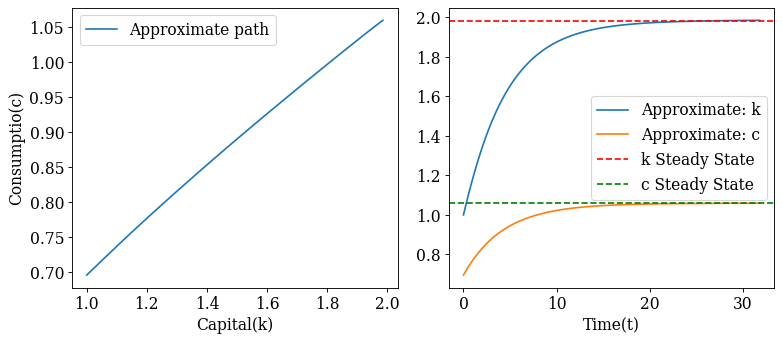

In [ ]:
plt.subplot(1, 2, 1)


plt.plot(k_hat_path,c_hat_path, label = r"Approximate path")
plt.ylabel(r"Consumptio(c)")
plt.xlabel(r"Capital(k)")
plt.legend(loc='best')

plt.subplot(1, 2, 2)
plt.plot(time_test,k_hat_path,label= r"Approximate: k")
plt.plot(time_test,c_hat_path,label= r"Approximate: c")
plt.axhline(y=SS().k_ss, color='r', linestyle='--',label="k Steady State")
plt.axhline(y=SS().c_ss, color='g', linestyle='--',label="c Steady State")

plt.xlabel(r"Time(t)")
plt.tight_layout()
plt.legend(loc='best')
plt.tight_layout()
plt.show()


## Plotting the results in the phase space


In [ ]:
def c_zero_path(k): # f(k)-delta k
    delta = Params().delta
    return f(k)-delta*k
k_mesh = torch.arange(1.0, 2.1 , 0.005)
c_zero_path_mesh = c_zero_path(k_mesh)

In [ ]:
c_grid,k_grid = np.meshgrid(np.linspace(0.6,1.1,30),np.linspace(1.0,2.1,30))

dcdt = (c_grid/Params().sigma)*(f_prime(k_grid)-(Params().delta+Params().rho))
dkdt = f(k_grid)-Params().delta*k_grid-c_grid

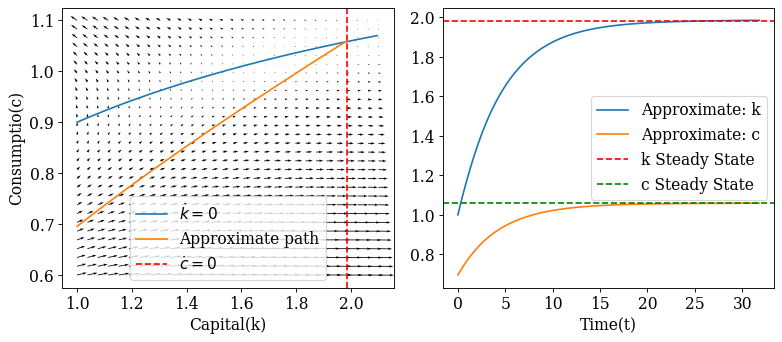

In [ ]:
plt.subplot(1, 2, 1)


plt.plot(k_mesh,c_zero_path_mesh,label= r"$\dot{k} = 0$")
plt.plot(k_hat_path,c_hat_path, label = r"Approximate path")
plt.axvline(x=SS().k_ss, color='r', linestyle='--',label=r"$\dot{c} = 0$")
plt.ylabel(r"Consumptio(c)")
plt.xlabel(r"Capital(k)")
plt.quiver(k_grid,c_grid,dkdt,dcdt)
plt.legend(loc='best')

plt.subplot(1, 2, 2)
plt.plot(time_test,k_hat_path,label= r"Approximate: k")
plt.plot(time_test,c_hat_path,label= r"Approximate: c")
plt.axhline(y=SS().k_ss, color='r', linestyle='--',label="k Steady State")
plt.axhline(y=SS().c_ss, color='g', linestyle='--',label="c Steady State")

plt.xlabel(r"Time(t)")
plt.tight_layout()
plt.legend(loc='best')
plt.tight_layout()
plt.show()



## Error analysis: Comparison with the shooting method

In [ ]:
from scipy.integrate import odeint

In [ ]:
def dg_dt(ck, t):
    sigma = Params().sigma
    delta = Params().delta
    rho = Params().rho
    return [(ck[0]/sigma)*( f_prime(ck[1])- (delta+rho) ), f(ck[1])-delta*ck[1] - ck[0]]

ts = np.linspace(0, 32, 107)
ck0 = [0.6954047,Params().k_0] #Be careful the c(0) = 0.6954047 is only for these parameters, you have to change it if you change the parameters of the problem
sol = odeint(dg_dt, ck0, ts)
c_path_shoot = sol[:,0]
k_path_shoot = sol[:,1]

In [ ]:
c_rel_error = (c_path_shoot - c_hat_path.squeeze().numpy())/c_path_shoot
k_rel_error = (k_path_shoot - k_hat_path.squeeze().numpy())/k_path_shoot

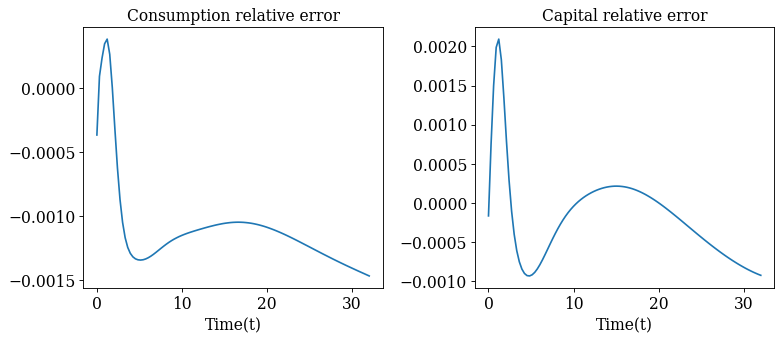

In [ ]:
plt.subplot(1, 2, 1)


plt.plot(ts,c_rel_error)
plt.xlabel(r"Time(t)")
plt.title(r"Consumption relative error")

plt.subplot(1, 2, 2)

plt.plot(ts,k_rel_error)
plt.xlabel(r"Time(t)")
plt.title(r"Capital relative error")
plt.tight_layout()
plt.show()


## Dynamic of the optimization process
The prpcces of finding a solution is an iterative process. The following video shows the convergence of this iterative procedure.

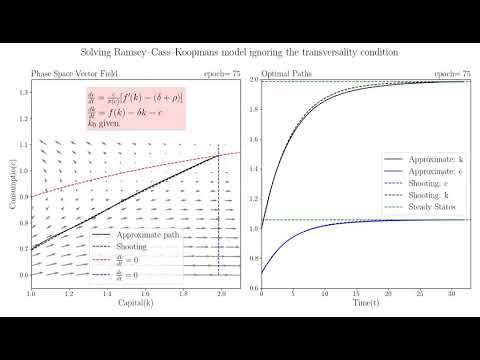

In [ ]:
from IPython.display import YouTubeVideo
id = 'B-zf73bID1o'
YouTubeVideo(id = id, width = 800, height= 600)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Parameter Calibration (Benhabib, Schmitt-Grohé, and Uribe 2001)
A = 2              # Active Taylor Rule coefficient
r = 0.018 / 4        # Steady-state real rate (quarterly)
pi_star = 0.042 / 4  # Central bank target inflation
R_star = r + pi_star # Target nominal interest rate

# Structural parameters
omega = -1.0
eta = -6.0
v = 1.0
alpha = 0.7
gamma = 50.0
x = 0.5

# Taylor Rule
def R(pi):
    return R_star * np.exp((A / R_star) * (pi - pi_star))

# 2. Define the Vector Field Function
def vector_field(lam, pi):
    # Ensure lambda is strictly positive to avoid warnings with fractional exponents on grid
    lam = np.maximum(lam, 1e-5)

    # d(lambda)/dt
    dlam = lam * (r + pi - R(pi))

    # d(pi)/dt
    term1 = r * (pi - pi_star)
    term2 = -((1 + eta) / gamma) * (lam ** (omega / (omega - 1))) * (x ** (1 / (1 - omega)))
    term3 = (eta / (gamma * alpha)) * (lam ** ((1 + v) / (alpha * (omega - 1)))) * (x ** ((1 + v) / (alpha * (1 - omega))))
    dpi = term1 + term2 + term3

    return dlam, dpi

# 3. Phase Space Grid Setup
# Define fixed grid limits for the phase space
L_min_pure, L_max_pure = 0.9, 1.0
P_min_pure, P_max_pure = -0.01, 0.015

L_grid_pure, P_grid_pure = np.meshgrid(
    np.linspace(L_min_pure, L_max_pure, 50),
    np.linspace(P_min_pure, P_max_pure, 50)
)

# Calculate vector field using the defined function
dL_pure, dP_pure = vector_field(L_grid_pure, P_grid_pure)

# 4. Plotting
plt.figure(figsize=(8, 6))

# Quiver plot for the vector field
plt.quiver(L_grid_pure[::3, ::3], P_grid_pure[::3, ::3], dL_pure[::3, ::3], dP_pure[::3, ::3], color='gray', alpha=0.6)

# Plot nullclines using contour (where dL=0 and dP=0)
plt.contour(L_grid_pure, P_grid_pure, dL_pure, levels=[0], colors='r', linestyles='--')
plt.contour(L_grid_pure, P_grid_pure, dP_pure, levels=[0], colors='g', linestyles='--')

plt.ylabel(r"Inflation ($\pi$)")
plt.xlabel(r"Marginal Utility of Wealth ($\lambda$)")

# Create custom legend
custom_lines = [Line2D([0], [0], color='r', linestyle='--', lw=2),
                Line2D([0], [0], color='g', linestyle='--', lw=2)]
plt.legend(custom_lines, [r'$\dot{\lambda}=0$', r'$\dot{\pi}=0$'], loc='best')

plt.title("Pure Phase Space Dynamics (Benhabib et al. 2001)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show or save the plot!
plt.show()